# 😴 Drowsiness Detection — Feature Extraction Pipeline
**Model:** MobileNetV2 (Feature Extractor) → SVM (Classifier)  
**Classes:** `drowsy` | `non_drowsy`

---
## 📋 Pipeline Overview
1. Load & validate dataset
2. Encode labels
3. Build TF datasets (NO augmentation during extraction)
4. Extract MobileNetV2 features
5. Normalize features with StandardScaler
6. Save everything for SVM training

---
## 1️⃣ Imports

In [17]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow version : 2.10.0
GPU available      : True


---
## 2️⃣ Configuration

In [18]:
# ── Paths ──────────────────────────────────────────────────────────────────
ROOT_DIR   = r"C:\Users\AmrAhmed\Desktop\Level 3\Second Term\Pattern Recognition\Project\Drowsiness-Project\datasets"
CLEAN_DIR  = os.path.join(ROOT_DIR, "clean_dataset")
CSV_PATH   = os.path.join(ROOT_DIR, "dataset_split.csv")
OUTPUT_DIR = os.path.join("extracted_features")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model / Data settings ──────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Fixed label map ────────────────────────────────────────────────────────
LABEL_MAP = {"drowsy": 1, "non_drowsy": 0}

print("Config OK")
print(f"  IMG_SIZE   = {IMG_SIZE}")
print(f"  BATCH_SIZE = {BATCH_SIZE}")
print(f"  LABEL_MAP  = {LABEL_MAP}")

Config OK
  IMG_SIZE   = 224
  BATCH_SIZE = 32
  LABEL_MAP  = {'drowsy': 1, 'non_drowsy': 0}


---
## 3️⃣ Load & Validate Dataset

In [19]:
# ── Build dataframe directly from folder structure ─────────────────────────
rows = []

for split in ["train", "test"]:
    for label in ["drowsy", "non_drowsy"]:
        folder = os.path.join(CLEAN_DIR, split, label)

        if not os.path.exists(folder):
            print(f"⚠️ Missing folder: {folder}")
            continue

        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            if os.path.isfile(fpath):
                rows.append({
                    "path": fpath,
                    "label": label,
                    "split": split
                })

df = pd.DataFrame(rows)

# ── Validate that files actually exist ─────────────────────────────────────
missing = df[~df["path"].apply(os.path.exists)]
if not missing.empty:
    print(f"⚠️  WARNING: {len(missing)} missing files — they will be dropped.")
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
else:
    print(f"✅ All {len(df)} image files found.")

# ── Validate labels ────────────────────────────────────────────────────────
unknown_labels = set(df["label"].unique()) - set(LABEL_MAP.keys())
assert not unknown_labels, f"Unknown labels found: {unknown_labels}"

print(f"\nDataset shape : {df.shape}")
print(df.groupby(["split", "label"]).size().to_string())

✅ All 28025 image files found.

Dataset shape : (28025, 3)
split  label     
test   drowsy         2865
       non_drowsy     2740
train  drowsy        11458
       non_drowsy    10962


---
## 4️⃣ Encode Labels & Split

In [20]:
df["label_enc"] = df["label"].map(LABEL_MAP)

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

NUM_CLASSES = len(LABEL_MAP)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")

# ── Check for class imbalance ──────────────────────────────────────────────
print("\n--- Train class distribution ---")
print(train_df["label"].value_counts())

imbalance_ratio = train_df["label"].value_counts().max() / train_df["label"].value_counts().min()
if imbalance_ratio > 1.5:
    print(f"\n⚠️  Imbalance ratio = {imbalance_ratio:.2f}  →  Use class_weight='balanced' in SVM!")
else:
    print(f"\n✅ Classes roughly balanced (ratio = {imbalance_ratio:.2f})")

Train samples : 22420
Test  samples : 5605

--- Train class distribution ---
label
drowsy        11458
non_drowsy    10962
Name: count, dtype: int64

✅ Classes roughly balanced (ratio = 1.05)


---
## 5️⃣ Image Preprocessing Function

> **Note:** `decode_image` is used instead of `decode_jpeg` to handle PNG / BMP / GIF as well.

In [21]:
def load_and_preprocess(path: tf.Tensor, label: tf.Tensor) -> tuple:
    """
    Load an image from disk, resize, cast, and apply MobileNetV2 preprocessing.
    No augmentation — this function is used for BOTH train and test feature extraction.
    """
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])           # Required after decode_image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)            # Scales to [-1, 1] for MobileNetV2
    return image, label


def make_dataset(dataframe: pd.DataFrame, shuffle: bool = False) -> tf.data.Dataset:
    """
    Build a batched, prefetched TF dataset from a dataframe.
    No augmentation is applied — augmentation is irrelevant for SVM feature extraction.
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["path"].values, dataframe["label_enc"].values)
    )
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=42)
    ds = (
        ds
        .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )
    return ds


print("✅ Preprocessing functions defined.")

✅ Preprocessing functions defined.


### 5.1 Quick Sanity-Check — Preview a Batch

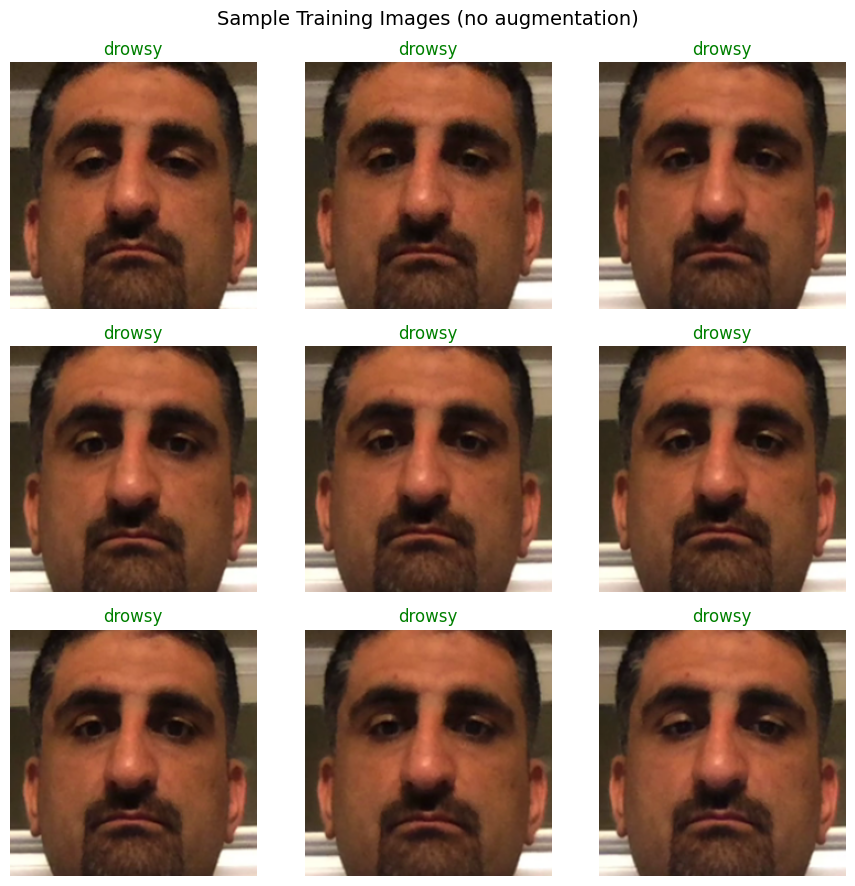

In [22]:
preview_ds = make_dataset(train_df.head(9))
images, labels = next(iter(preview_ds))

# Undo MobileNetV2 scaling for visualization only
display_imgs = (images.numpy() + 1.0) / 2.0
display_imgs = np.clip(display_imgs, 0, 1)

inv_label_map = {v: k for k, v in LABEL_MAP.items()}

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, img, lbl in zip(axes.flat, display_imgs, labels.numpy()):
    ax.imshow(img)
    ax.set_title(inv_label_map[lbl], fontsize=12,
                 color="red" if lbl == 0 else "green")
    ax.axis("off")
plt.suptitle("Sample Training Images (no augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 6️⃣ Build MobileNetV2 Feature Extractor

In [23]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False   # Freeze — we're only extracting features

x = GlobalAveragePooling2D()(base_model.output)

feature_extractor = Model(inputs=base_model.input, outputs=x)

print(f"Feature vector size : {feature_extractor.output_shape[1]}")
print(f"Trainable params    : {feature_extractor.count_params():,}")

Feature vector size : 1280
Trainable params    : 2,257,984


---
## 7️⃣ Extract Features

> ⚠️ **Important:** Both train and test datasets are created **without augmentation**.  
> Augmentation only makes sense during end-to-end neural network training, not for SVM feature extraction.

In [24]:
train_ds = make_dataset(train_df, shuffle=False)
test_ds  = make_dataset(test_df,  shuffle=False)

print("Extracting TRAIN features...")
X_train_raw = feature_extractor.predict(train_ds, verbose=1)
y_train     = train_df["label_enc"].values
print(f"  Shape: {X_train_raw.shape}")

print("\nExtracting TEST features...")
X_test_raw = feature_extractor.predict(test_ds, verbose=1)
y_test     = test_df["label_enc"].values
print(f"  Shape: {X_test_raw.shape}")

Extracting TRAIN features...
701/701 [==============================] - 16s 23ms/step
  Shape: (22420, 1280)

Extracting TEST features...
176/176 [==============================] - 4s 23ms/step
  Shape: (5605, 1280)


---
## 8️⃣ Normalize Features (StandardScaler)

> SVMs are sensitive to feature scale.  
> `fit` only on train, then `transform` both train and test.

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)   # Fit on train only
X_test  = scaler.transform(X_test_raw)        # Apply same scaler to test

print("After StandardScaler:")
print(f"  X_train  mean ≈ {X_train.mean():.4f}  std ≈ {X_train.std():.4f}")
print(f"  X_test   mean ≈ {X_test.mean():.4f}  std ≈ {X_test.std():.4f}")

After StandardScaler:
  X_train  mean ≈ -0.0000  std ≈ 1.0000
  X_test   mean ≈ 0.0033  std ≈ 1.0015


---
## 9️⃣ Save All Artifacts

In [26]:
# ── Features & Labels ──────────────────────────────────────────────────────
np.save(os.path.join(OUTPUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUTPUT_DIR, "X_test.npy"),  X_test)
np.save(os.path.join(OUTPUT_DIR, "y_test.npy"),  y_test)

# ── Scaler (must be applied to any new image at inference time) ────────────
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))

# ── Label map (for reproducible decoding) ─────────────────────────────────
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(LABEL_MAP, f, indent=2)

print("✅ Saved to", OUTPUT_DIR)
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   {fname:<30} {size_kb:>8.1f} KB")

✅ Saved to extracted_features
   label_map.json                      0.0 KB
   scaler.pkl                         30.6 KB
   X_test.npy                      28025.1 KB
   X_train.npy                    112100.1 KB
   y_test.npy                         43.9 KB
   y_train.npy                       175.3 KB


---
## 🔟 Summary & Next Steps

In [27]:
print("=" * 55)
print("  FEATURE EXTRACTION COMPLETE")
print("=" * 55)
print(f"  Train samples    : {X_train.shape[0]}")
print(f"  Test  samples    : {X_test.shape[0]}")
print(f"  Feature dim      : {X_train.shape[1]}")
print(f"  Scaler           : StandardScaler (fitted on train)")
print(f"  Output directory : {OUTPUT_DIR}/")
print("=" * 55)
print()
print("Next → open 02_svm_training.ipynb")
print()
print("Recommended SVM settings:")
print("  from sklearn.svm import SVC")
print("  model = SVC(kernel='rbf', C=1.0,")

imbalance_ratio = train_df["label"].value_counts().max() / train_df["label"].value_counts().min()
if imbalance_ratio > 1.5:
    print("                class_weight='balanced',  # imbalance detected")
print("                probability=True)          # for confidence scores")

  FEATURE EXTRACTION COMPLETE
  Train samples    : 22420
  Test  samples    : 5605
  Feature dim      : 1280
  Scaler           : StandardScaler (fitted on train)
  Output directory : extracted_features/

Next → open 02_svm_training.ipynb

Recommended SVM settings:
  from sklearn.svm import SVC
  model = SVC(kernel='rbf', C=1.0,
                probability=True)          # for confidence scores
